In [1]:
import xarray as xr 
print("success")

success


In [2]:
import xarray as xr
import numpy as np
from pathlib import Path

# ============================================================
# PATHS
# ============================================================

files = {
    "SST": r"C:\OceanF\data\processed\SST\SST_processed.nc",
    "SSS": r"C:\OceanF\data\processed\SSS\SSS_processed.nc",
    "SSA": r"C:\OceanF\data\processed\SSA\SSA_processed.nc",
    "Currents": r"C:\OceanF\data\processed\Currents\Currents_processed.nc",
    "Winds": r"C:\OceanF\data\processed\Winds\Winds_processed.nc",
    "SubsurfaceTemp": r"C:\OceanF\data\processed\SubsurfaceTemp\SubsurfaceTemp_processed.nc",
}

datasets = {}

for name, path in files.items():

    print(f"Loading {name}...")

    ds = xr.open_dataset(path)

    # Standardize Winds coordinate name
    if "valid_time" in ds.coords and "time" not in ds.coords:
        ds = ds.rename({"valid_time": "time"})

    # Standardize latitude orientation
    if "latitude" in ds.coords:
        if ds.latitude.values[0] > ds.latitude.values[-1]:
            ds = ds.sortby("latitude")

    datasets[name] = ds

print("\n✓ All datasets loaded.")

Loading SST...
Loading SSS...
Loading SSA...
Loading Currents...
Loading Winds...
Loading SubsurfaceTemp...

✓ All datasets loaded.


In [3]:
# ============================================================
# OCEANF TARGET GRID
# ============================================================

TARGET_RESOLUTION = 0.25

TARGET_LAT = np.arange(
    5.0,
    30.0 + TARGET_RESOLUTION / 2,
    TARGET_RESOLUTION,
    dtype=np.float32
)

TARGET_LON = np.arange(
    45.0,
    105.0 + TARGET_RESOLUTION / 2,
    TARGET_RESOLUTION,
    dtype=np.float32
)

print("Target grid")
print("-" * 50)

print("Latitude:")
print(f"  Range : {TARGET_LAT[0]} → {TARGET_LAT[-1]}")
print(f"  Count : {len(TARGET_LAT)}")

print("\nLongitude:")
print(f"  Range : {TARGET_LON[0]} → {TARGET_LON[-1]}")
print(f"  Count : {len(TARGET_LON)}")

print("\nFinal spatial shape:")
print(f"  {len(TARGET_LAT)} × {len(TARGET_LON)}")

Target grid
--------------------------------------------------
Latitude:
  Range : 5.0 → 30.0
  Count : 101

Longitude:
  Range : 45.0 → 105.0
  Count : 241

Final spatial shape:
  101 × 241


In [4]:
# ============================================================
# SPATIAL HARMONIZATION TO 0.25°
# ============================================================

target_grid = {
    "latitude": TARGET_LAT,
    "longitude": TARGET_LON,
}

harmonized_spatial = {}

for name, ds in datasets.items():

    print("=" * 75)
    print(f"Harmonizing {name}")
    print("=" * 75)

    ds_h = ds.interp(
        latitude=TARGET_LAT,
        longitude=TARGET_LON,
        method="linear",
        kwargs={
            "fill_value": np.nan
        }
    )

    harmonized_spatial[name] = ds_h

    print("Original shape:", ds.sizes)
    print("New shape     :", ds_h.sizes)

Harmonizing SST
Original shape: Frozen({'time': 455, 'latitude': 500, 'longitude': 1200})
New shape     : Frozen({'time': 455, 'latitude': 101, 'longitude': 241})
Harmonizing SSS
Original shape: Frozen({'time': 604, 'latitude': 200, 'longitude': 480})
New shape     : Frozen({'time': 604, 'latitude': 101, 'longitude': 241})
Harmonizing SSA
Original shape: Frozen({'time': 381, 'latitude': 200, 'longitude': 480})
New shape     : Frozen({'time': 381, 'latitude': 101, 'longitude': 241})
Harmonizing Currents
Original shape: Frozen({'time': 609, 'latitude': 100, 'longitude': 240})
New shape     : Frozen({'time': 609, 'latitude': 101, 'longitude': 241})
Harmonizing Winds
Original shape: Frozen({'time': 184, 'latitude': 101, 'longitude': 241})
New shape     : Frozen({'time': 184, 'latitude': 101, 'longitude': 241})
Harmonizing SubsurfaceTemp
Original shape: Frozen({'time': 184, 'depth': 15, 'latitude': 101, 'longitude': 241})
New shape     : Frozen({'time': 184, 'depth': 15, 'latitude': 101, 'l

In [5]:
# ============================================================
# SPATIAL HARMONIZATION QC
# ============================================================

print("=" * 90)
print("FINAL SPATIAL HARMONIZATION QC")
print("=" * 90)

for name, ds in harmonized_spatial.items():

    lat = ds.latitude.values
    lon = ds.longitude.values

    lat_ok = np.array_equal(lat, TARGET_LAT)
    lon_ok = np.array_equal(lon, TARGET_LON)

    shape_ok = (
        len(lat) == 101 and
        len(lon) == 241
    )

    lat_ascending = np.all(np.diff(lat) > 0)
    lon_ascending = np.all(np.diff(lon) > 0)

    print(
        f"\n{name}"
    )
    print(
        f"  Shape              : {len(lat)} × {len(lon)}"
    )
    print(
        f"  Latitude grid      : {'PASS ✓' if lat_ok else 'FAIL ✗'}"
    )
    print(
        f"  Longitude grid     : {'PASS ✓' if lon_ok else 'FAIL ✗'}"
    )
    print(
        f"  Shape              : {'PASS ✓' if shape_ok else 'FAIL ✗'}"
    )
    print(
        f"  Latitude ascending : {'PASS ✓' if lat_ascending else 'FAIL ✗'}"
    )
    print(
        f"  Longitude ascending: {'PASS ✓' if lon_ascending else 'FAIL ✗'}"
    )

    if not (lat_ok and lon_ok and shape_ok):
        raise ValueError(
            f"Spatial harmonization failed for {name}"
        )

print("\n" + "=" * 90)
print("✓ ALL DATASETS ARE ON THE EXACT OCEANF 0.25° GRID")
print("=" * 90)

FINAL SPATIAL HARMONIZATION QC

SST
  Shape              : 101 × 241
  Latitude grid      : PASS ✓
  Longitude grid     : PASS ✓
  Shape              : PASS ✓
  Latitude ascending : PASS ✓
  Longitude ascending: PASS ✓

SSS
  Shape              : 101 × 241
  Latitude grid      : PASS ✓
  Longitude grid     : PASS ✓
  Shape              : PASS ✓
  Latitude ascending : PASS ✓
  Longitude ascending: PASS ✓

SSA
  Shape              : 101 × 241
  Latitude grid      : PASS ✓
  Longitude grid     : PASS ✓
  Shape              : PASS ✓
  Latitude ascending : PASS ✓
  Longitude ascending: PASS ✓

Currents
  Shape              : 101 × 241
  Latitude grid      : PASS ✓
  Longitude grid     : PASS ✓
  Shape              : PASS ✓
  Latitude ascending : PASS ✓
  Longitude ascending: PASS ✓

Winds
  Shape              : 101 × 241
  Latitude grid      : PASS ✓
  Longitude grid     : PASS ✓
  Shape              : PASS ✓
  Latitude ascending : PASS ✓
  Longitude ascending: PASS ✓

SubsurfaceTemp
  Shap

In [6]:
# ============================================================
# MISSING-DATA QC AFTER SPATIAL HARMONIZATION
# ============================================================

print("=" * 90)
print("MISSING-DATA ANALYSIS")
print("=" * 90)

for name, ds in harmonized_spatial.items():

    print(f"\n{name}")
    print("-" * 90)

    for var_name, da in ds.data_vars.items():

        # Count missing values
        missing = int(da.isnull().sum().compute())

        # Total values
        total = da.size

        # Percentage
        missing_pct = 100.0 * missing / total

        print(
            f"{var_name:20s} | "
            f"missing = {missing:,} / {total:,} "
            f"({missing_pct:.4f}%)"
        )

MISSING-DATA ANALYSIS

SST
------------------------------------------------------------------------------------------
sst                  | missing = 5,739,825 / 11,075,155 (51.8261%)

SSS
------------------------------------------------------------------------------------------
sss                  | missing = 7,840,524 / 14,701,964 (53.3298%)

SSA
------------------------------------------------------------------------------------------
sla                  | missing = 4,776,978 / 9,273,921 (51.5098%)
err_ugosa            | missing = 4,776,978 / 9,273,921 (51.5098%)
vgos                 | missing = 4,807,458 / 9,273,921 (51.8385%)

Currents
------------------------------------------------------------------------------------------
uo                   | missing = 7,970,322 / 14,823,669 (53.7675%)
vo                   | missing = 7,970,436 / 14,823,669 (53.7683%)

Winds
------------------------------------------------------------------------------------------
u_wind               | mi

In [7]:
# ============================================================
# SPATIAL MISSING-DATA FRACTION
# ============================================================

print("=" * 90)
print("SPATIAL MISSING-DATA FRACTION")
print("=" * 90)

surface_datasets = [
    "SST",
    "SSS",
    "SSA",
    "Currents",
    "Winds",
]

for name in surface_datasets:

    ds = harmonized_spatial[name]

    print(f"\n{name}")
    print("-" * 90)

    for var_name, da in ds.data_vars.items():

        # Fraction of time missing at each grid cell
        missing_fraction = (
            da.isnull()
            .mean(dim="time")
            .compute()
        )

        print(
            f"{var_name:20s} | "
            f"min={float(missing_fraction.min()):.4f} | "
            f"max={float(missing_fraction.max()):.4f} | "
            f"mean={float(missing_fraction.mean()):.4f}"
        )

SPATIAL MISSING-DATA FRACTION

SST
------------------------------------------------------------------------------------------
sst                  | min=0.0000 | max=1.0000 | mean=0.5183

SSS
------------------------------------------------------------------------------------------
sss                  | min=0.0000 | max=1.0000 | mean=0.5333

SSA
------------------------------------------------------------------------------------------
sla                  | min=0.0000 | max=1.0000 | mean=0.5151
err_ugosa            | min=0.0000 | max=1.0000 | mean=0.5151
vgos                 | min=0.0000 | max=1.0000 | mean=0.5184

Currents
------------------------------------------------------------------------------------------
uo                   | min=0.0016 | max=1.0000 | mean=0.5377
vo                   | min=0.0016 | max=1.0000 | mean=0.5377

Winds
------------------------------------------------------------------------------------------
u_wind               | min=0.0000 | max=0.0000 | mean=0.

In [8]:
# ============================================================
# SUBSURFACE TARGET MISSINGNESS BY DEPTH
# ============================================================

thetao = harmonized_spatial["SubsurfaceTemp"]["thetao"]

print("=" * 90)
print("SUBSURFACE TEMPERATURE MISSINGNESS BY DEPTH")
print("=" * 90)

for depth in thetao.depth.values:

    da = thetao.sel(depth=depth)

    missing = int(da.isnull().sum().compute())
    total = da.size

    missing_pct = 100.0 * missing / total

    print(
        f"Depth {float(depth):7.1f} m | "
        f"missing = {missing:,} / {total:,} "
        f"({missing_pct:.2f}%)"
    )

SUBSURFACE TEMPERATURE MISSINGNESS BY DEPTH
Depth     0.0 m | missing = 2,349,128 / 4,478,744 (52.45%)
Depth     5.0 m | missing = 2,349,128 / 4,478,744 (52.45%)
Depth    10.0 m | missing = 2,412,608 / 4,478,744 (53.87%)
Depth    20.0 m | missing = 2,461,552 / 4,478,744 (54.96%)
Depth    30.0 m | missing = 2,518,960 / 4,478,744 (56.24%)
Depth    50.0 m | missing = 2,612,064 / 4,478,744 (58.32%)
Depth    75.0 m | missing = 2,677,936 / 4,478,744 (59.79%)
Depth   100.0 m | missing = 2,716,208 / 4,478,744 (60.65%)
Depth   125.0 m | missing = 2,723,568 / 4,478,744 (60.81%)
Depth   150.0 m | missing = 2,735,344 / 4,478,744 (61.07%)
Depth   200.0 m | missing = 2,753,376 / 4,478,744 (61.48%)
Depth   300.0 m | missing = 2,767,912 / 4,478,744 (61.80%)
Depth   500.0 m | missing = 2,799,560 / 4,478,744 (62.51%)
Depth   700.0 m | missing = 2,826,608 / 4,478,744 (63.11%)
Depth  1000.0 m | missing = 2,874,264 / 4,478,744 (64.18%)


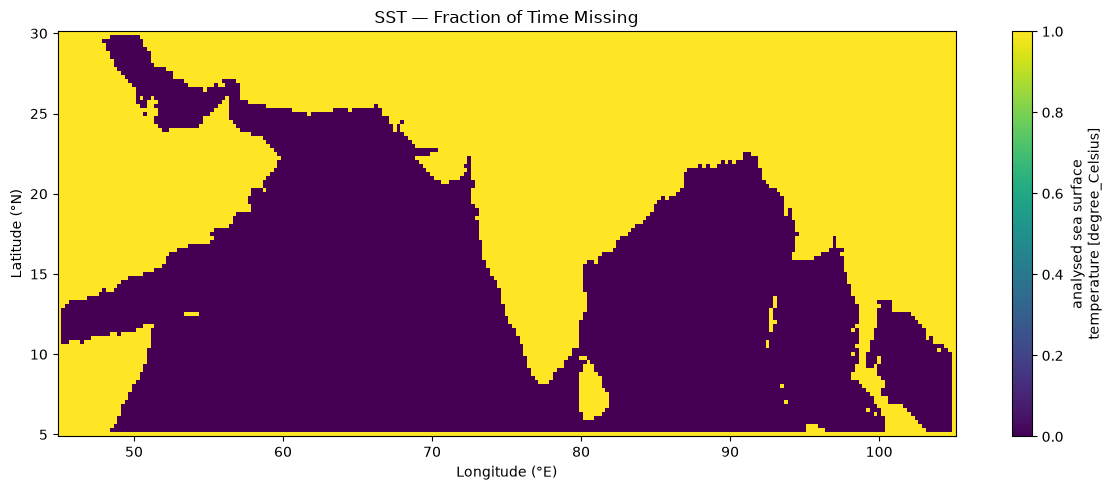

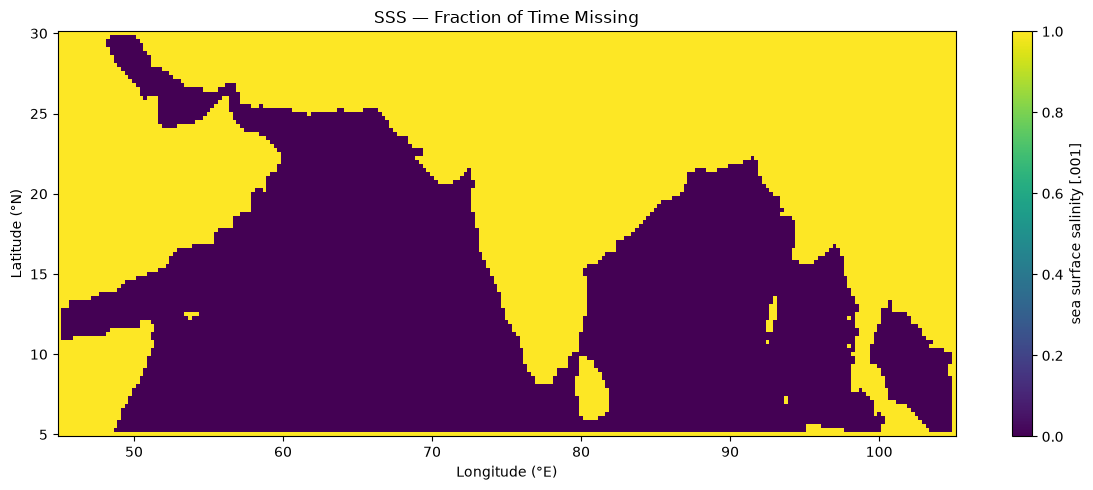

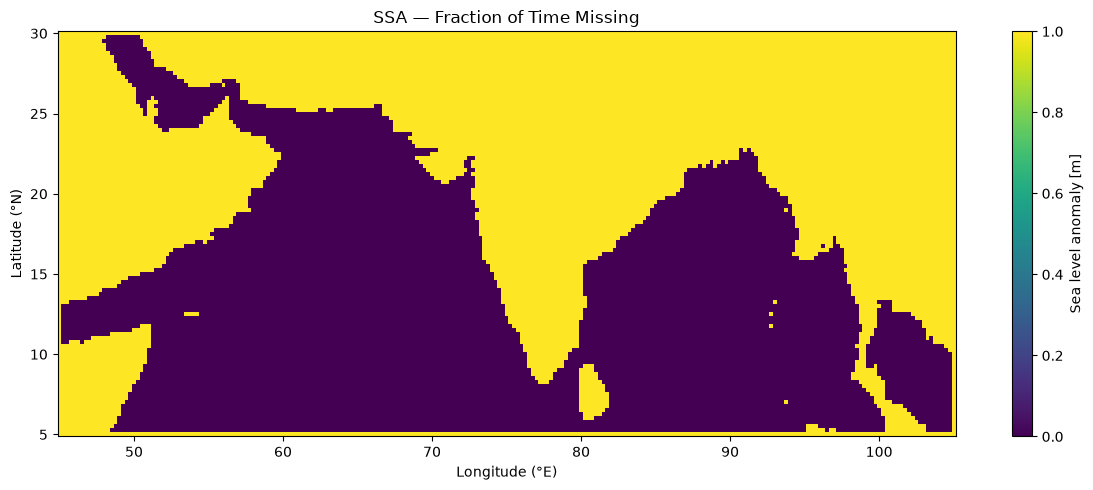

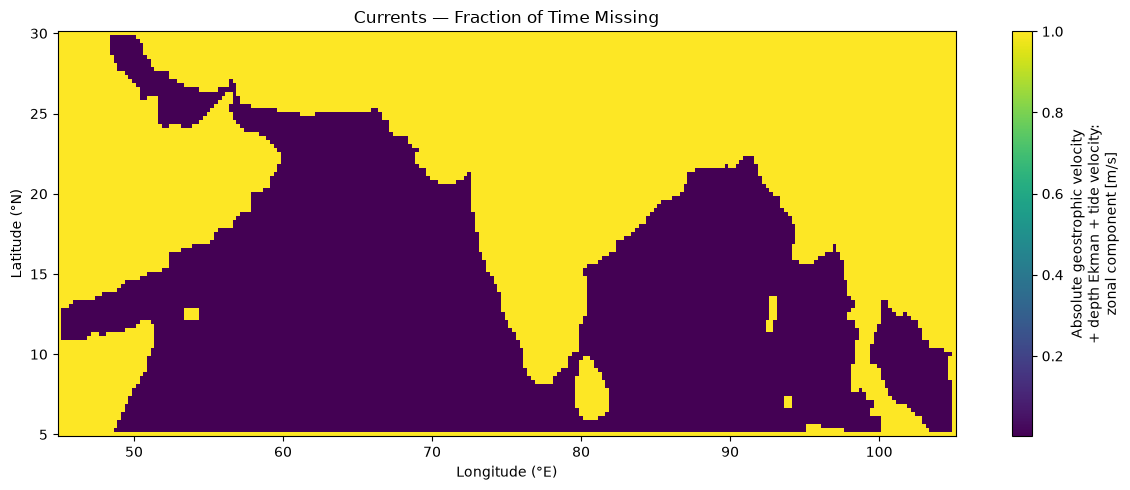

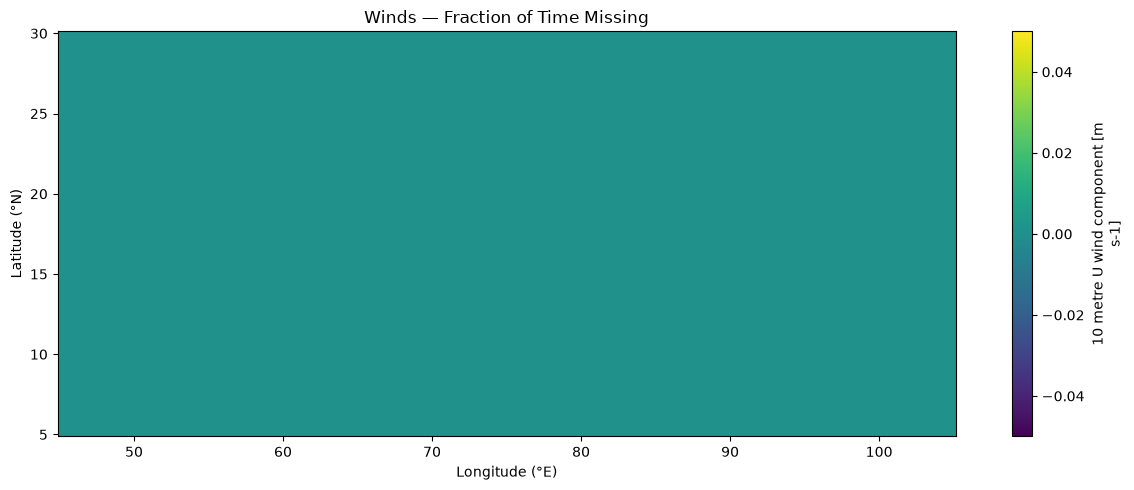

In [9]:
# ============================================================
# MISSING-DATA MAPS
# ============================================================

import matplotlib.pyplot as plt

surface_variables = {
    "SST": "sst",
    "SSS": "sss",
    "SSA": "sla",
    "Currents": "uo",
    "Winds": "u_wind",
}

for dataset_name, variable_name in surface_variables.items():

    da = harmonized_spatial[dataset_name][variable_name]

    # Fraction of time each grid cell is missing
    missing_fraction = (
        da.isnull()
        .mean(dim="time")
        .compute()
    )

    plt.figure(figsize=(12, 5))

    missing_fraction.plot(
        x="longitude",
        y="latitude"
    )

    plt.title(
        f"{dataset_name} — Fraction of Time Missing"
    )

    plt.xlabel("Longitude (°E)")
    plt.ylabel("Latitude (°N)")

    plt.tight_layout()
    plt.show()


u_wind
Min missing fraction: 0.000000
Max missing fraction: 0.000000
Mean missing fraction: 0.000000


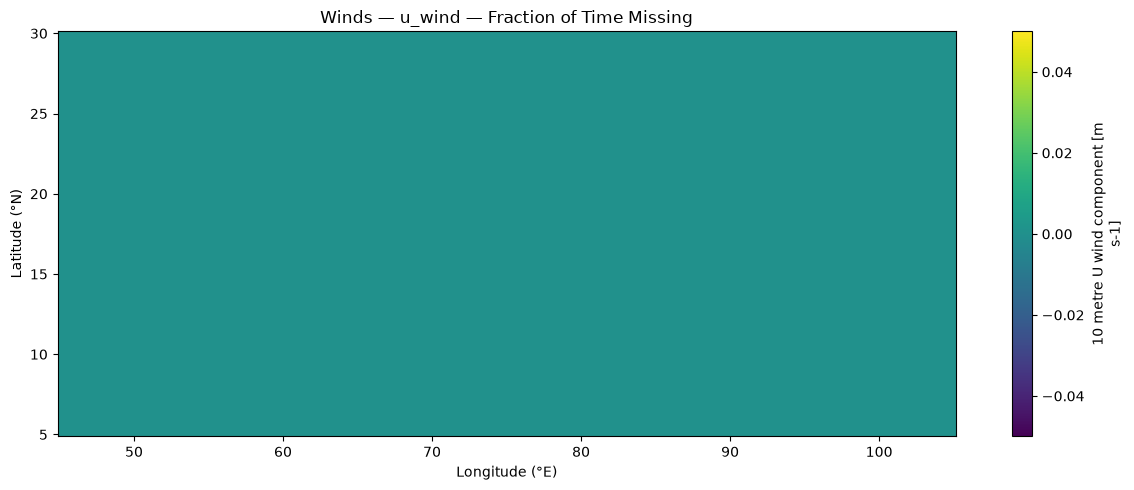


v_wind
Min missing fraction: 0.000000
Max missing fraction: 0.000000
Mean missing fraction: 0.000000


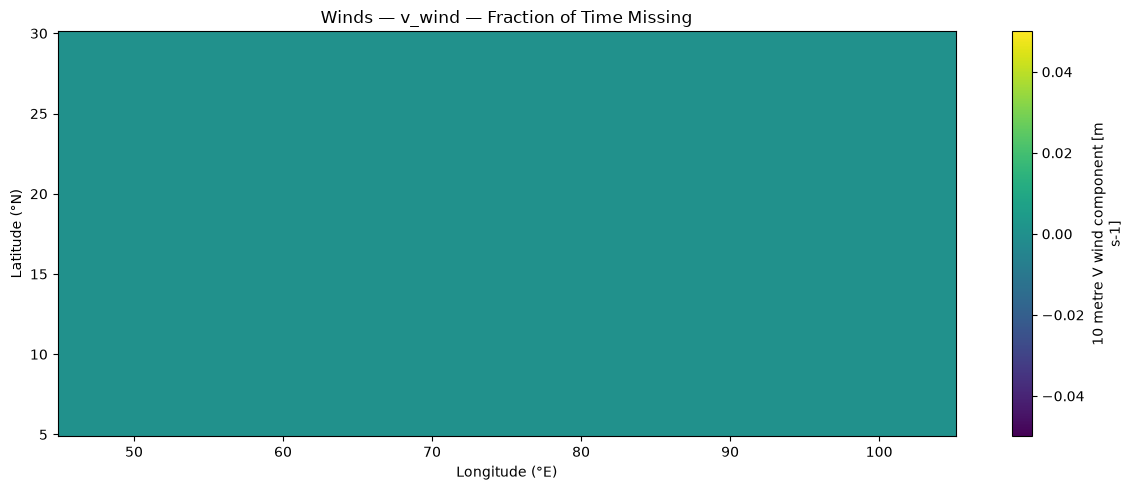


wind_speed
Min missing fraction: 0.000000
Max missing fraction: 0.000000
Mean missing fraction: 0.000000


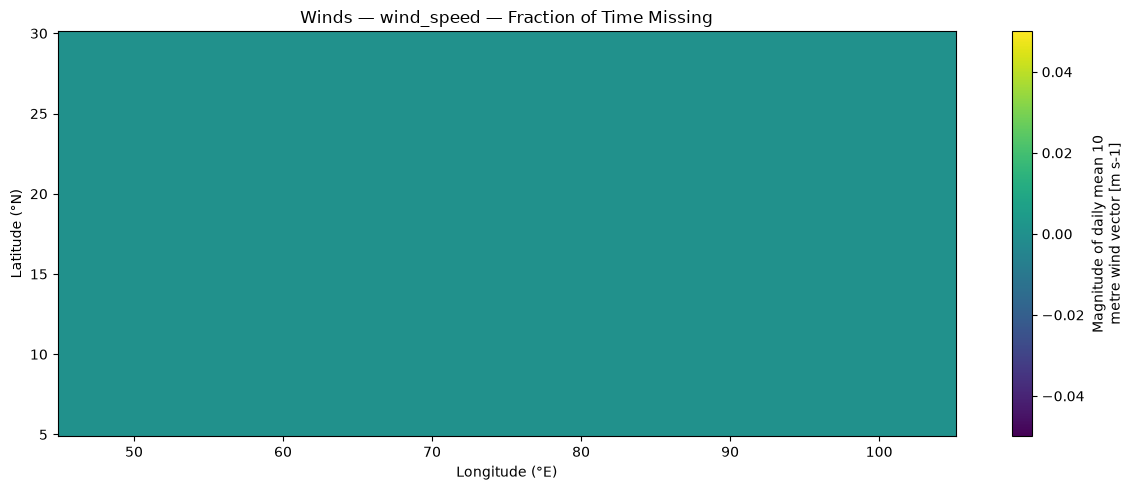

In [10]:
# ============================================================
# WINDS — MISSINGNESS / COVERAGE CHECK
# ============================================================

wind_vars = ["u_wind", "v_wind", "wind_speed"]

for variable_name in wind_vars:

    da = harmonized_spatial["Winds"][variable_name]

    # Fraction missing over time
    missing_fraction = da.isnull().mean(dim="time").compute()

    print(f"\n{variable_name}")
    print(f"Min missing fraction: {float(missing_fraction.min()):.6f}")
    print(f"Max missing fraction: {float(missing_fraction.max()):.6f}")
    print(f"Mean missing fraction: {float(missing_fraction.mean()):.6f}")

    plt.figure(figsize=(12, 5))

    missing_fraction.plot(
        x="longitude",
        y="latitude"
    )

    plt.title(f"Winds — {variable_name} — Fraction of Time Missing")
    plt.xlabel("Longitude (°E)")
    plt.ylabel("Latitude (°N)")
    plt.tight_layout()
    plt.show()

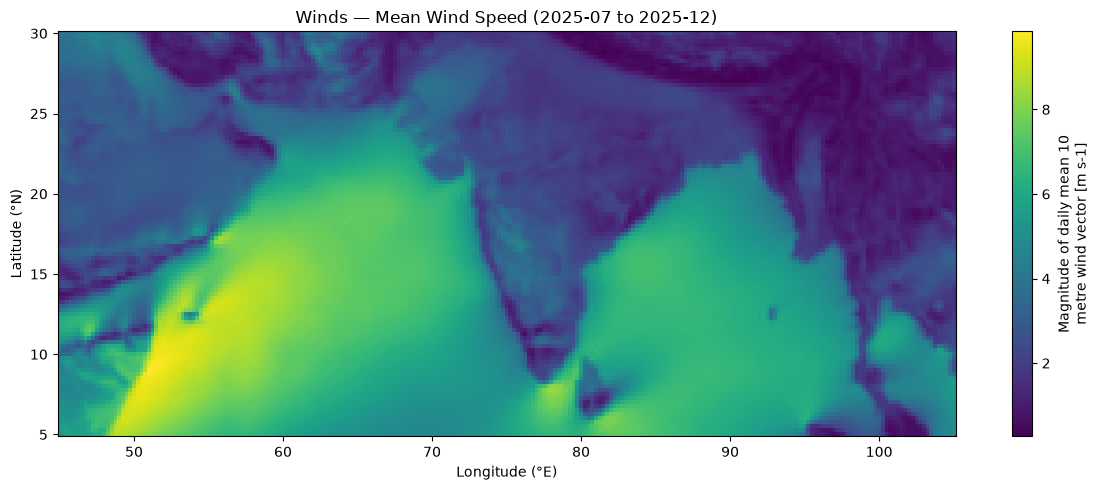

In [11]:
# ============================================================
# WINDS — ACTUAL DATA COVERAGE
# ============================================================

wind_speed = harmonized_spatial["Winds"]["wind_speed"]

# Mean wind speed over the full period
mean_wind_speed = wind_speed.mean(dim="time").compute()

plt.figure(figsize=(12, 5))

mean_wind_speed.plot(
    x="longitude",
    y="latitude"
)

plt.title("Winds — Mean Wind Speed (2025-07 to 2025-12)")
plt.xlabel("Longitude (°E)")
plt.ylabel("Latitude (°N)")
plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# WINDS — VALID DATA COUNT
# ============================================================

wind_speed = harmonized_spatial["Winds"]["wind_speed"]

valid_count = wind_speed.notnull().sum(dim="time").compute()

print("Minimum valid days:", int(valid_count.min()))
print("Maximum valid days:", int(valid_count.max()))
print("Expected days:", wind_speed.sizes["time"])

Minimum valid days: 184
Maximum valid days: 184
Expected days: 184
